# ReFRAME library dataset analysis

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

from benchmarking.metrics.base_metrics import (
    compute_precision_recall_data,
    compute_precision_recall_data_all,
    load_all_feature_tables,
)

from benchmarking.loader import (
    get_ccs_error_distributions,
    get_confident_tps,
)

from benchmarking.plots import (
    plot_true_positive_overlap,
    plot_ccs_distribution,
    plot_pr_curves,
    plot_pr_curves_multi,
)

# Load in data

In [2]:
ground_truth_library_data = pd.read_parquet(
    "../data/library_spectra/reframe_spikein_lib.pq"
)
ground_truth_ccs_data = pd.read_parquet(
    "../data/library_spectra/reframe_ms2s_with_ccs.parquet"
)

In [3]:
# Building the feature table for reframe_spikein_dataset
merged_feature_tables = load_all_feature_tables(
    ["../data/groundtruth_dataset/MSV000098263"],
    annotation_subfolder="annotated_spectral_entropy",
)

100%|██████████| 1/1 [00:23<00:00, 23.98s/it]


# Figure 3a: F1 vs Spectral entropy score threshold

In [4]:
score_range, precision_recall_curves, confusion_matrix_data = (
    compute_precision_recall_data(
        merged_feature_tables=merged_feature_tables,
        ground_truth_data=ground_truth_library_data,
        score_threshold=0.7,
    )
)

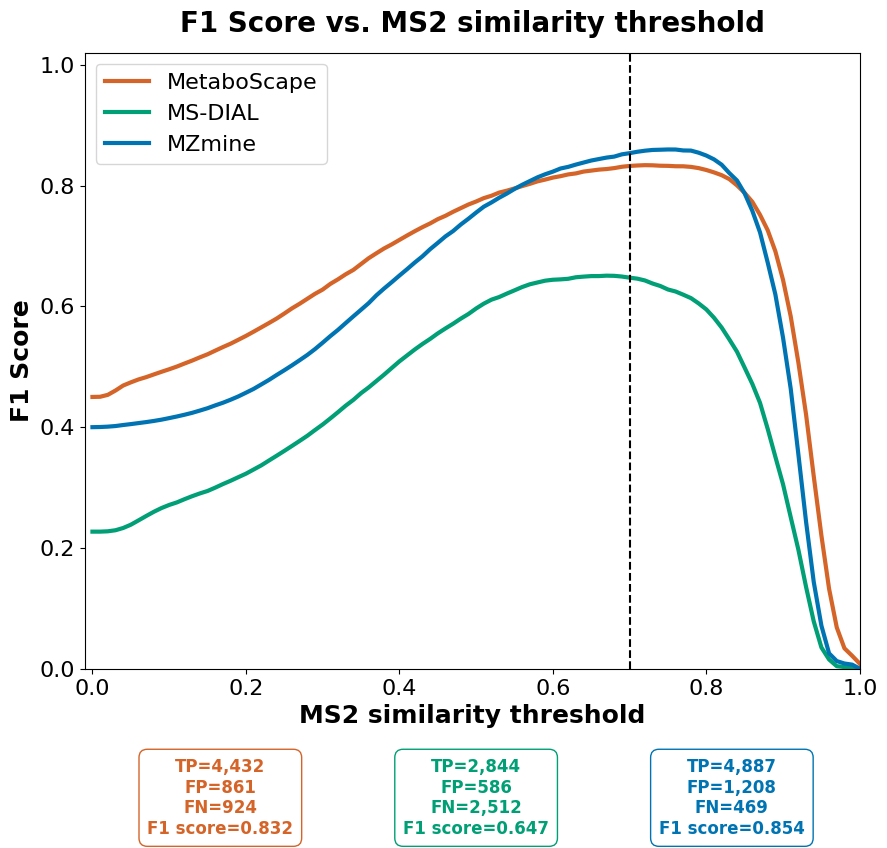

In [5]:
plot_pr_curves(
    score_range,
    precision_recall_curves,
    confusion_matrix_data,
    x_var="score",
    y_var="f1",
    confusion_matrix_threshold=0.7,
    title="F1 Score vs. MS2 similarity threshold",
    fig_size=(10, 8),
    save_path="../figures/figure_3a.png",
)

# Figure 3b: F1 score distribution across other annotation metrics for MZMine tool

In [6]:
# Get the mzmine based feature tables only
annotation_types = [
    "annotated_spectral_entropy",
    "annotated_cosine_similarity",
    "annotated_dreams_similarity",
]

# Getting the relevant tables
combined_feature_table_list = defaultdict(pd.DataFrame)

for annotation_subfolder in annotation_types:
    combined_feature_table_list[annotation_subfolder] = load_all_feature_tables(
        ["../data/groundtruth_dataset/MSV000098263"],
        annotation_subfolder=annotation_subfolder,
    )

100%|██████████| 1/1 [00:23<00:00, 23.86s/it]


In [7]:
# Subset to keeping only the mzmine based annotations for now
mzmine_combined_feature_table_list = {
    ann_type: {tool: df for tool, df in df_dict.items() if tool == "mzmine"}
    for ann_type, df_dict in combined_feature_table_list.items()
}

In [8]:
# Compute precision/recall for all annotation types at once
score_range, all_precision_recall_curves, all_confusion_matrix_data = (
    compute_precision_recall_data_all(
        merged_feature_tables=mzmine_combined_feature_table_list,
        ground_truth_data=ground_truth_library_data,
        confusion_matrix_threshold=0.7,
    )
)

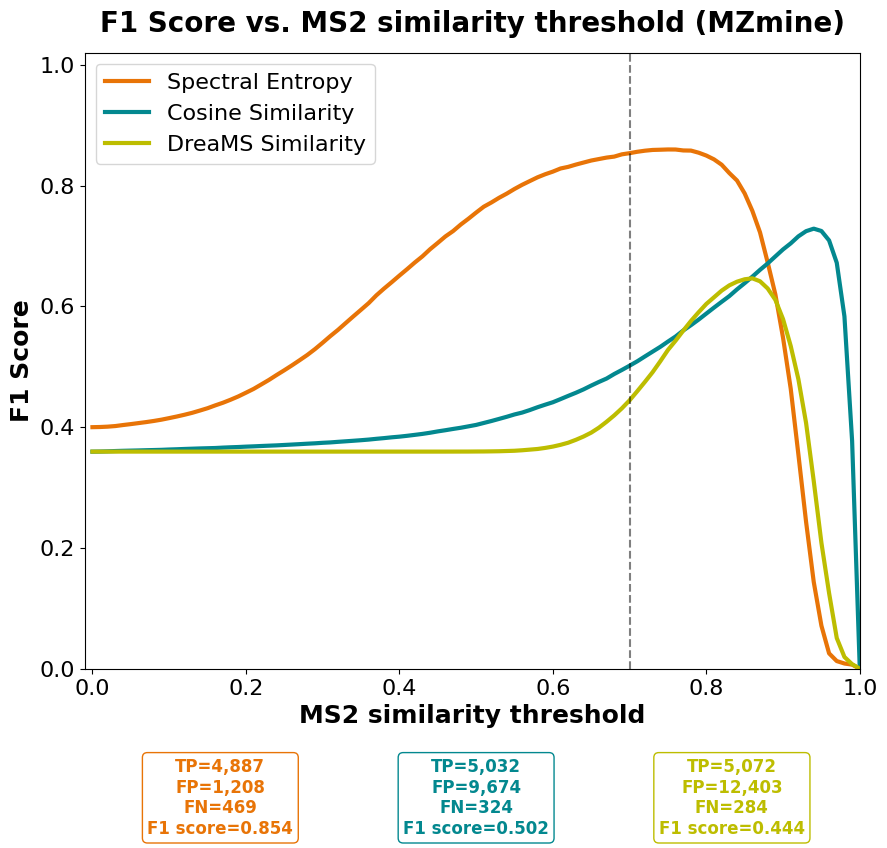

In [9]:
plot_pr_curves_multi(
    score_range=score_range,
    all_precision_recall_curves=all_precision_recall_curves,
    all_confusion_matrix_data=all_confusion_matrix_data,
    x_var="score",
    y_var="f1",
    confusion_matrix_threshold=0.7,
    title="F1 Score vs. MS2 similarity threshold (MZmine)",
    save_path="../figures/figure_3b.png",
    fig_size=(10, 8),
)

# Figure 3c: Overlapping true positives

In [10]:
confident_tps = get_confident_tps(
    merged_feature_tables=merged_feature_tables,
    ground_truth_library_data=ground_truth_library_data,
    spectral_score_threshold=0.7,
)

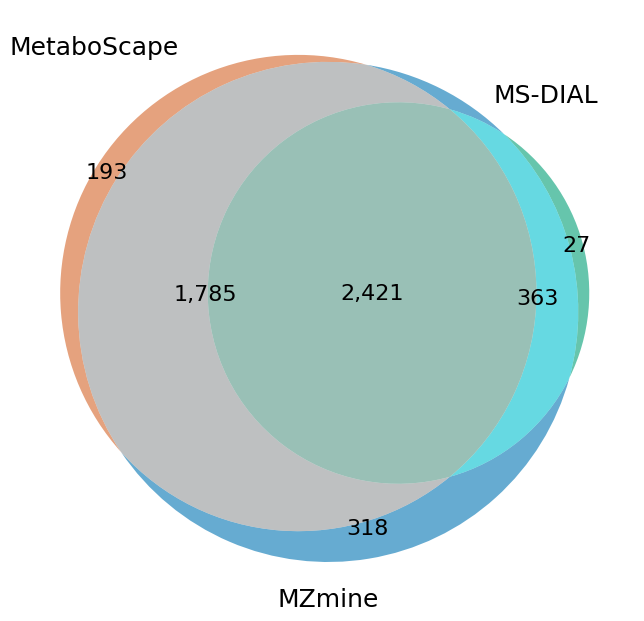

In [11]:
plot_true_positive_overlap(
    tool_inchikeys=confident_tps,
    title=None,
    figsize=(8, 8),
    save_path="../figures/figure_3c.png",
)

# Figure 3d: Compute and plot CCS error

In [12]:
ccs_error_distributions = get_ccs_error_distributions(
    merged_feature_tables, ground_truth_ccs_data
)

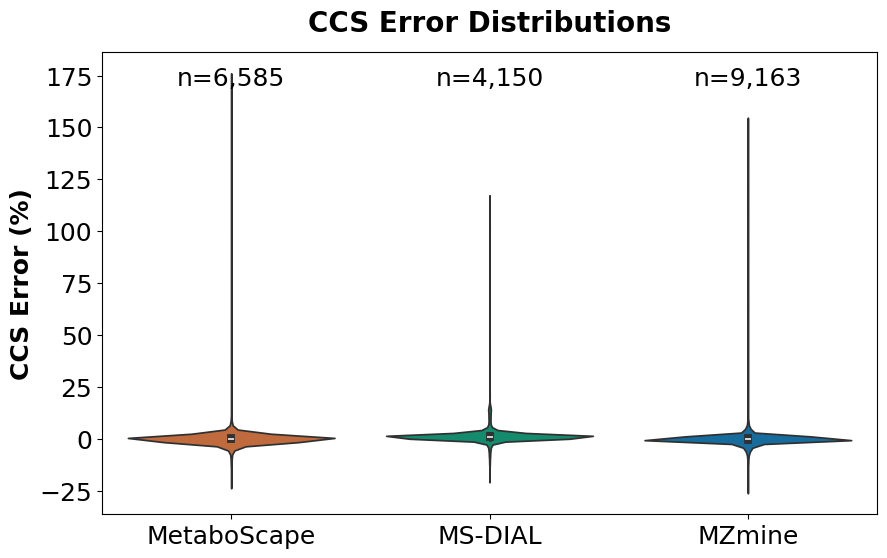

In [13]:
plot_ccs_distribution(
    ccs_error_distributions,
    output_type="relative",
    save_path="../figures/figure_3d.png",
    show_points=False,
    figsize=(10, 6),
)

In [14]:
data_to_plot = []
labels = []

ccs_error_distributions = dict(sorted(ccs_error_distributions.items()))
for tool, errors in ccs_error_distributions.items():
    data_to_plot.append(errors)
    labels.append(tool)

plot_df = pd.DataFrame(
    {
        "Software": np.repeat(labels, [len(errors) for errors in data_to_plot]),
        "CCS Error (%)": np.concatenate(data_to_plot),
    }
)

# Calcuate the percentage of error within 5% CCS error for each software
error_within_5_percent = {
    tool: np.mean(np.abs(errors) <= 5) * 100
    for tool, errors in ccs_error_distributions.items()
}
error_within_1_percent = {
    tool: np.mean(np.abs(errors) <= 1) * 100
    for tool, errors in ccs_error_distributions.items()
}

print("Percentage of CCS errors within 5%:")
for tool, percentage in error_within_5_percent.items():
    print(f"{tool}: {percentage:.2f}%")

print("\nPercentage of CCS errors within 1%:")
for tool, percentage in error_within_1_percent.items():
    print(f"{tool}: {percentage:.2f}%")

Percentage of CCS errors within 5%:
metaboscape: 96.87%
msdial: 94.60%
mzmine: 95.68%

Percentage of CCS errors within 1%:
metaboscape: 82.32%
msdial: 57.98%
mzmine: 76.25%
